In [19]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

## Problemă: Ce îi poate face pe oameni fericiți?

 Se consideră problema predicției gradului de fericire a populației globului folosind informații despre diferite caracteristici a bunăstării respectivei populații precum Produsul intern brut al țării în care locuiesc (gross domestic product – GBP), gradul de fericire, etc.  Folsind datele aferente anului 2017 [here](https://www.kaggle.com/unsdsn/world-happiness#2017.csv), să se realizeze o predicție a gradului de fericire în funcție de Family.

### Deci avem o problema de regresie univariata $y = w_0 + w_1 * x$, unde:
- o variabila dependenta – y (gradul de fericire) si
- o variabila independenta – x (Family).

### Pasi in rezolvare:
* plot pt distributia datelor & plot pt “verificarea” liniaritatii (daca legatura intre y si x e una liniara)
* impartire date pe train si test
* invatare model (cu tool generic si cu tool de least square)
* plot rezultate
* calcul metrici de performanta (eroarea)

## Rezolvarea problemei cu tool cu un parametru

#### Pasul 1 - plot pt distributia datelor & plot pt “verificarea” liniaritatii (daca legatura intre y si x e una liniara)

In [20]:
def loadData(fileName, inputVariableName, outputVariableName):
    data = []
    dataNames = []

    with open(fileName) as csv_file: # deschidem csv-ul
        csv_reader = csv.reader(csv_file, delimiter=',') # citim datele din csv
        line_count = 0 # suntem pe prima linie
        for row in csv_reader:
            if line_count == 0: # daca suntem pe prima linie, atunci inseamna ca suntem pe headerul tabelului
                dataNames = row # salvam numele coloanelor
            else: # daca nu suntem pe prima linie, atunci salvam datele de pe randul curent
                data.append(row)
            line_count += 1
        selectedVariable = dataNames.index(inputVariableName) # cautam pe ce index se afla coloana cu numele inputVariableName
        inputs = [float(data[i][selectedVariable]) for i in range(len(data))] # salvam valorile din coloana respectiva
        selectedOutput = dataNames.index(outputVariableName) # cautam pe ce index se afla coloana cu numele outputVariableName
        outputs = [float(data[i][selectedOutput]) for i in range(len(data))] # salvam valorile din coloana respectiva

    return inputs, outputs

In [21]:
crtDir = os.getcwd() # luam calea catre folderul curent
filePath = os.path.join(crtDir, 'data', 'v3_world-happiness-report-2017.csv') # construim calea catre csv

inputs, outputs = loadData(filePath, 'Family', 'Happiness.Score') # incarcam datele din csv
# inputs = normalizeData(inputs) # normalizam datele de intrare

print('input data: ', inputs[:5])
print('output data: ', outputs[:5])

input data:  [1.53352356, 1.551121593, 1.610574007, 1.516911745, 1.540246725]
output data:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


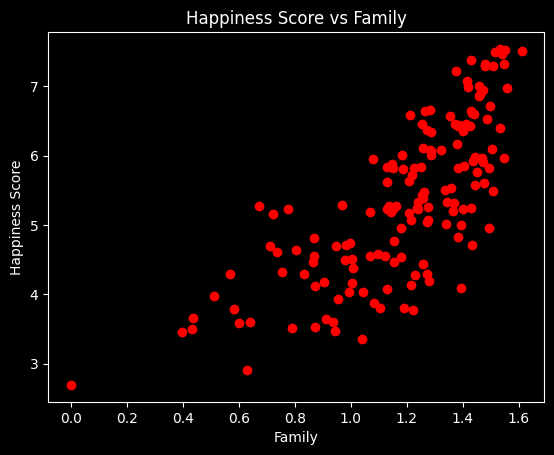

In [22]:
plt.plot(inputs, outputs, 'ro') # afisam datele sub forma de puncte rosii
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.title('Happiness Score vs Family')
plt.show()

O clasificam intr-o problema de regresie liniara, deoarece se pare ca exista o legatura liniara intre cele doua variabile (se poate observa din plotul de mai sus).

<img src="images/regression.png" width="200">

#### Pasul 2 - impartire date pe train si validation

In [23]:
# Impartim datele pe train si validation (80% train, 20% validation)
np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False) # alegem aleator 80% din indexi pentru train
validationSample = [i for i in indexes if i not in trainSample] # restul de indexi vor fi pentru validation

trainInputs = [inputs[i] for i in trainSample] # datele de intrare pentru train
trainOutputs = [outputs[i] for i in trainSample] # datele de iesire pentru train

validationInputs = [inputs[i] for i in validationSample] # datele de intrare pentru validation
validationOutputs = [outputs[i] for i in validationSample] # datele de iesire pentru validation

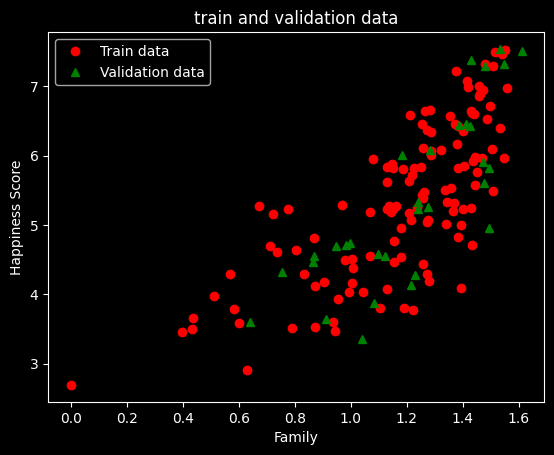

In [24]:
plt.plot(trainInputs, trainOutputs, 'ro', label='Train data') # afisam datele de train sub forma de puncte rosii
plt.plot(validationInputs, validationOutputs, 'g^', label='Validation data') # afisam datele de validation sub forma de triunghiuri verzi
plt.title('train and validation data')
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.legend()
plt.show()

#### Pasul 3 - invatare model (cu tool generic si cu tool de least square)

In [25]:
# Antrenam modelul de regresie liniara folosind sklearn
# Sklearn are nevoie ca si input un training data care este de forma (noSamples x noFeatures array)
# In cazul nostru data o sa contina len(trainInputs) pentru linii, adica noSample si pentru noFeatures array o sa avem un vector cu un singur element (singurul nostru feature)
sklearn_input = [[feature] for feature in trainInputs]

regressor = linear_model.LinearRegression()
# pentru a gasi a si b sau w0 si w1 vom folosi functie de training care asteapta inputul pentru sklearn si outputurile cu care sa verifice predictia
regressor.fit(sklearn_input, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_[0]
print('The model learnt: f(x) = ', w0, ' + ', w1, ' * x')

The model learnt: f(x) =  2.0390139300228456  +  2.8049136175570775  * x


#### Pasul 4 - plot rezultate (model invatat, predictii)

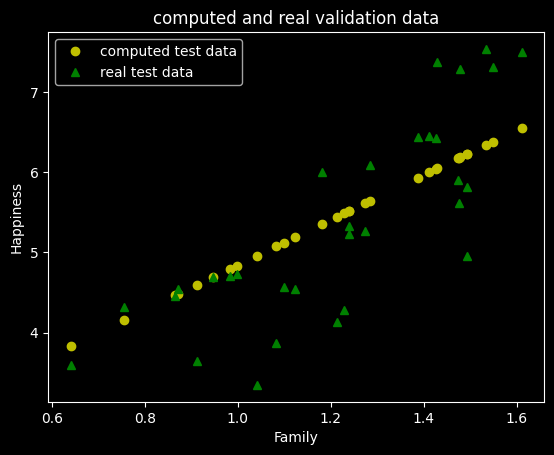

In [26]:
# Plotam linia pe care modelul a invatat-o peste datele reale
# Preparam niste data, unde input-urile sunt random, iar output-urile sunt computate de model
# Plotam mai intai peste datele de training
noOfPoints = 1000 # cate puncte vrem sa generam pentru a trasa linia
xref = []
val = min(trainInputs) # incepem de la cel mai mic input
step = (max(trainInputs) - min(trainInputs)) / noOfPoints # distanta dintre puncte
for i in range(1, noOfPoints): # construim xref, care va contine noOfPoints numere intre min(trainInputs) si max(trainInputs)
    xref.append(val)
    val += step
yref = [w0 + w1 * x for x in xref]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')
plt.plot(xref, yref, 'b-', label = 'learnt model')
plt.title('computed and real training data')
plt.xlabel('Family')
plt.ylabel('Happiness')
plt.legend()
plt.show()

# Plotam dupa peste datele de validare
computedValidationOutputs = regressor.predict([[feature] for feature in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data')
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data')
plt.title('computed and real validation data')
plt.xlabel('Family')
plt.ylabel('Happiness')
plt.legend()
plt.show()

#### Pasul 5 - calcul metrici de performanta (eroarea)

In [27]:
# Calculam eroarea medie patratica pentru datele de validare cu sklearn
mean_abs_error = 0.0
for t1, t2 in zip(validationOutputs, computedValidationOutputs):
    mean_abs_error += abs(t1 - t2)
mean_abs_error /= len(validationOutputs)
print('mean absolute error:', mean_abs_error)

mean_squared_error = mean_squared_error(validationOutputs, computedValidationOutputs)
print('mean squared error (tool):  ', mean_squared_error)

mean absolute error: 0.6262605660371917
mean squared error (tool):   0.6051231125473608
